<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/Fundamentals_and_Applications/dz_topic_12_Sofiia_Bobrivets_AL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання до теми 12
## Метод k-means. Ієрархічний кластерний аналіз

**Студентка:** Sofiia Bobrivets  
**Курс:** Machine Learning: Fundamentals and Applications

### Мета роботи
Виконати кластеризацію рецептур бетону з набору **Concrete** методом K-Means:
- створити ознаку `Components`;
- нормалізувати дані;
- визначити оптимальну кількість кластерів методом Elbow;
- отримати мітки кластерів;
- сформувати звіт з медіанами ознак та кількістю рецептур у кожному кластері;
- проаналізувати отримані групи.


## 1. Імпорт бібліотек

In [1]:
%pip -q install yellowbrick

import pickle
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


## 2. Завантаження набору даних Concrete

In [2]:
url = "https://github.com/goitacademy/MACHINE-LEARNING-NEO/raw/refs/heads/main/datasets/mod_05_topic_10_various_data.pkl"
file_name = "mod_05_topic_10_various_data.pkl"

urllib.request.urlretrieve(url, file_name)

with open(file_name, "rb") as file:
    data = pickle.load(file)

print("Доступні набори:", list(data.keys()))

concrete = data["concrete"].copy()

print("\nРозмір Concrete:", concrete.shape)
display(concrete.head())


Доступні набори: ['autos', 'concrete', 'customer', 'accidents']

Розмір Concrete: (427, 8)


,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength
0,102.0,153.0,0.0,192.0,0.0,887.0,942.0,25.46
1,108.3,162.4,0.0,203.5,0.0,938.2,849.0,29.23
2,116.0,173.0,0.0,192.0,0.0,909.8,891.9,31.02
3,122.6,183.9,0.0,203.5,0.0,958.2,800.1,33.19
4,132.0,206.5,160.9,178.9,5.5,866.9,735.6,33.31


## 3. Первинна перевірка даних

In [3]:
print("Типи даних:")
display(concrete.dtypes.to_frame("dtype"))

print("\nКількість пропусків:")
display(concrete.isna().sum().to_frame("missing"))

print("\nОписова статистика:")
display(concrete.describe().T)


Типи даних:


,dtype
Cement,float64
BlastFurnaceSlag,float64
FlyAsh,float64
Water,float64
Superplasticizer,float64
CoarseAggregate,float64
FineAggregate,float64
CompressiveStrength,float64



Кількість пропусків:


,missing
Cement,0
BlastFurnaceSlag,0
FlyAsh,0
Water,0
Superplasticizer,0
CoarseAggregate,0
FineAggregate,0
CompressiveStrength,0



Описова статистика:


,count,mean,std,min,25%,50%,75%,max
Cement,427.0,264.473302,103.514168,102.00,161.100,260.90,322.10,540.0
BlastFurnaceSlag,427.0,84.038876,87.875995,0.00,0.000,76.00,155.75,359.4
FlyAsh,427.0,62.110070,66.315352,0.00,0.000,24.50,119.90,200.1
Water,427.0,183.828103,19.278850,121.80,173.250,185.70,193.30,247.0
Superplasticizer,427.0,6.744262,5.404379,0.00,0.000,7.40,10.00,32.2
CoarseAggregate,427.0,957.004450,84.019091,801.00,882.800,955.10,1021.50,1145.0
FineAggregate,427.0,764.478454,73.259242,594.00,712.000,770.10,812.00,992.6
CompressiveStrength,427.0,39.008454,15.576297,8.54,28.785,38.11,48.41,82.6


## 4. Створення ознаки `Components`

Ознака `Components` показує, скільки складових фактично використано в кожній рецептурі бетону.  
Для підрахунку беремо стовпці зі складовими суміші та рахуємо кількість значень, більших за нуль.

`CompressiveStrength` не є складовою рецептури, тому в підрахунок `Components` не входить.


In [4]:
TARGET = "CompressiveStrength"

# Усі вхідні колонки, крім міцності, є характеристиками рецептури.
# Для Components враховуємо саме компоненти суміші, а не цільову змінну.
component_columns = [
    col for col in concrete.columns
    if col != TARGET
]

concrete["Components"] = (concrete[component_columns] > 0).sum(axis=1)

print("Колонки, використані для підрахунку Components:")
print(component_columns)

print("\nРозподіл кількості компонентів:")
display(concrete["Components"].value_counts().sort_index().to_frame("count"))

display(concrete.head())


Колонки, використані для підрахунку Components:
['Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water', 'Superplasticizer', 'CoarseAggregate', 'FineAggregate']

Розподіл кількості компонентів:


,count
Components,
4,69
5,67
6,171
7,120


,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength,Components
0,102.0,153.0,0.0,192.0,0.0,887.0,942.0,25.46,5
1,108.3,162.4,0.0,203.5,0.0,938.2,849.0,29.23,5
2,116.0,173.0,0.0,192.0,0.0,909.8,891.9,31.02,5
3,122.6,183.9,0.0,203.5,0.0,958.2,800.1,33.19,5
4,132.0,206.5,160.9,178.9,5.5,866.9,735.6,33.31,7


## 5. Підготовка та нормалізація

Для кластеризації використовуємо вхідні характеристики рецептури разом із новою ознакою `Components`.

Цільову характеристику `CompressiveStrength` не включаємо до ознак, за якими K-Means формує кластери. Після кластеризації вона буде використана у звіті для порівняння міцності отриманих груп.


In [5]:
cluster_features = [
    col for col in concrete.columns
    if col != TARGET
]

X = concrete[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Ознаки для кластеризації:")
print(cluster_features)
print("\nФорма нормалізованого набору:", X_scaled.shape)

scaled_check = pd.DataFrame(
    X_scaled,
    columns=cluster_features
)

display(scaled_check.describe().loc[["mean", "std"]])


Ознаки для кластеризації:
['Cement', 'BlastFurnaceSlag', 'FlyAsh', 'Water', 'Superplasticizer', 'CoarseAggregate', 'FineAggregate', 'Components']

Форма нормалізованого набору: (427, 8)


,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,Components
mean,0.000000,1.664035e-17,0.000000,-1.248026e-17,-7.072147e-17,-8.236971e-16,-1.672355e-15,4.492893e-16
std,1.001173,1.001173e+00,1.001173,1.001173e+00,1.001173e+00,1.001173e+00,1.001173e+00,1.001173e+00


## 6. Визначення оптимальної кількості кластерів

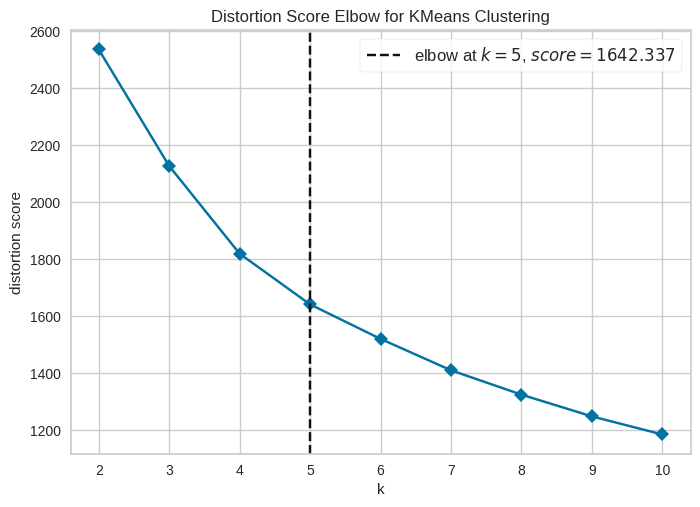

Оптимальна кількість кластерів: 5


In [6]:
base_model = KMeans(
    random_state=RANDOM_STATE,
    n_init=10
)

visualizer = KElbowVisualizer(
    base_model,
    k=(2, 11),
    metric="distortion",
    timings=False
)

visualizer.fit(X_scaled)
visualizer.show()

optimal_k = visualizer.elbow_value_

if optimal_k is None:
    raise ValueError(
        "KElbowVisualizer не визначив elbow_value_. "
        "Оберіть k за графіком Elbow та задайте optimal_k вручну."
    )

print("Оптимальна кількість кластерів:", optimal_k)


## 7. Кластеризація методом K-Means

In [7]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=RANDOM_STATE,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

concrete_report = concrete.copy()
concrete_report["Cluster"] = cluster_labels + 1

print("Кількість об'єктів у кластерах:")
display(
    concrete_report["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)


Кількість об'єктів у кластерах:


,Count
Cluster,
1,84
2,85
3,118
4,53
5,87


## 8. Описова статистика кластерів

Для звіту використовуємо **оригінальні, немасштабовані значення**.  
Для кожного кластера розраховуємо медіани всіх ознак, включаючи `Components` та `CompressiveStrength`, а також додаємо кількість рецептур.


In [8]:
cluster_medians = (
    concrete_report
    .groupby("Cluster")
    .median(numeric_only=True)
)

cluster_counts = (
    concrete_report
    .groupby("Cluster")
    .size()
    .rename("Count")
)

cluster_summary = cluster_medians.join(cluster_counts)

display(cluster_summary)


,Cement,BlastFurnaceSlag,FlyAsh,Water,Superplasticizer,CoarseAggregate,FineAggregate,CompressiveStrength,Components,Count
Cluster,,,,,,,,,,
1,212.3,0.00,125.2,169.95,9.9,1002.0,795.55,39.880,6.0,84
2,186.2,183.40,0.0,190.00,0.0,977.0,734.30,37.430,5.0,85
3,193.0,119.25,116.0,193.55,8.5,879.6,744.10,33.175,7.0,118
4,356.0,121.00,0.0,162.00,10.0,914.3,803.70,59.000,6.0,53
5,342.0,0.00,0.0,186.00,0.0,1040.0,774.00,36.940,4.0,87


## 9. Додаткове порівняння кластерів

In [9]:
strength_summary = (
    cluster_summary[[TARGET, "Components", "Count"]]
    .sort_values(TARGET, ascending=False)
)

print("Кластери від найбільшої медіанної міцності до найменшої:")
display(strength_summary)

strongest_cluster = strength_summary.index[0]
weakest_cluster = strength_summary.index[-1]

print(f"Кластер з найбільшою медіанною міцністю: {strongest_cluster}")
print(f"Кластер з найменшою медіанною міцністю: {weakest_cluster}")


Кластери від найбільшої медіанної міцності до найменшої:


,CompressiveStrength,Components,Count
Cluster,,,
4,59.000,6.0,53
1,39.880,6.0,84
2,37.430,5.0,85
5,36.940,4.0,87
3,33.175,7.0,118


Кластер з найбільшою медіанною міцністю: 4
Кластер з найменшою медіанною міцністю: 3


## 10. Висновки

У роботі було виконано кластеризацію набору даних Concrete методом K-Means.
Для кожної рецептури створено нову ознаку `Components`, яка показує кількість
задіяних складових. Перед кластеризацією дані було нормалізовано за допомогою
`StandardScaler`.

За допомогою методу Elbow було визначено оптимальну кількість кластерів — 5.
У результаті K-Means розподілив 427 рецептур на кластери, що містять
84, 85, 118, 53 та 87 об'єктів відповідно.

Порівняння медіан показало, що отримані кластери відрізняються не лише
співвідношенням складових, але й міцністю бетону. Найвищу медіанну міцність
має кластер 4 — 59.0, тоді як найнижчу має кластер 3 — 33.175.

Цікавим результатом є те, що кластер 3 має медіанно 7 компонентів — найбільше
серед отриманих груп, але при цьому найнижчу медіанну міцність. Кластер 4
має медіанно 6 компонентів і демонструє найвищу міцність. Отже, сама кількість
компонентів не визначає міцність бетону: важливими є їхній склад та
співвідношення.

Кластеризація дозволила виділити групи рецептур із різними характеристиками
та отримати додаткову інформацію про структуру набору даних. Отримані
результати можуть бути використані для подальшого дослідження факторів,
які найбільше впливають на міцність бетону.
які найбільше впливають на міцність бетону.
